In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import math

In [75]:
!pip install yfinance

In [76]:
import yfinance as yf

df = yf.download("RELIANCE.NS", start="2015-01-01", end="2025-01-01")

df.head()

/tmp/ipykernel_699/3967561202.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("RELIANCE.NS", start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2015-01-01,189.125381,189.998697,188.220116,188.784586,2963643
2015-01-02,188.624817,190.861356,188.358571,189.167973,7331366
2015-01-05,186.558701,189.764404,186.185942,188.507680,10103941
2015-01-06,178.091812,185.951626,177.218496,185.312621,18627980
2015-01-07,181.968460,182.926975,178.283514,178.304813,20720312


In [77]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)



Shape of Dataset: (2467, 5)

Column Names:
MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])


In [78]:
print("\nDataset Information:")
df.info()
print("\nStatistical Summary:")
display(df.describe())




Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2467 entries, 2015-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   2467 non-null   float64
 1   (High, RELIANCE.NS)    2467 non-null   float64
 2   (Low, RELIANCE.NS)     2467 non-null   float64
 3   (Open, RELIANCE.NS)    2467 non-null   float64
 4   (Volume, RELIANCE.NS)  2467 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 115.6 KB

Statistical Summary:


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,2467.000000,2467.000000,2467.000000,2467.000000,2.467000e+03
mean,727.334673,735.286782,720.016264,727.858117,1.842886e+07
std,417.918038,421.804235,414.359225,418.219568,1.355224e+07
min,172.692200,174.172571,169.646258,173.938275,1.705656e+06
25%,314.200302,316.146975,311.719235,314.407489,1.069616e+07
50%,639.086304,649.973734,633.653745,642.426013,1.464381e+07
75%,1116.204773,1128.412156,1106.930633,1117.631562,2.109197e+07
max,1581.824463,1589.630354,1566.607971,1585.332124,1.426834e+08


In [79]:
print("\nLast 5 Rows:")
display(df.tail())


Last 5 Rows:


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2024-12-24,1212.280762,1222.988340,1210.545745,1211.834663,6734917
2024-12-26,1206.133911,1217.188348,1203.853555,1213.767935,10016178
2024-12-27,1210.595459,1217.386785,1206.580087,1207.869004,7000397
2024-12-30,1200.333984,1212.726960,1197.756270,1205.985254,8818766
2024-12-31,1205.043213,1208.661986,1195.822913,1197.657049,6405475


In [80]:
print("Missing Values:")
print(df.isnull().sum())

df.dropna(inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Missing Values:
Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

Missing Values After Cleaning:
Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64


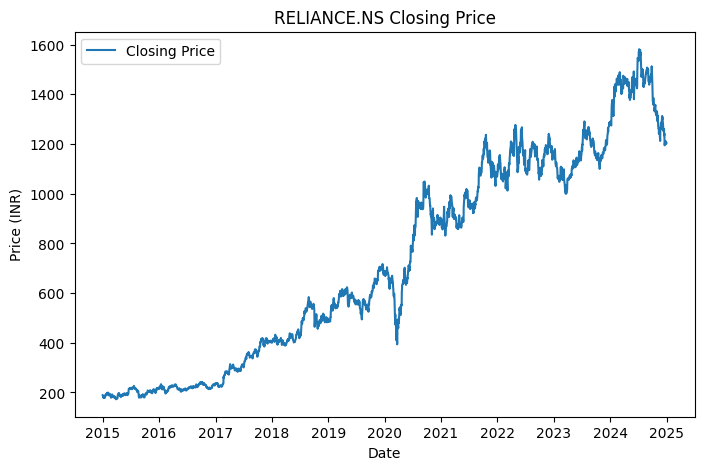

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(df['Close'], label='Closing Price')

plt.title('RELIANCE.NS Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()

plt.show()

In [82]:
data = df[['Close']]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

scaled_data[:5]

array([[0.01166192],
       [0.01130669],
       [0.00984045],
       [0.00383187],
       [0.00658296]])

In [83]:
X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2407, 60)
y shape: (2407,)


In [84]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1925, 60)
Testing Data: (482, 60)


In [85]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1925, 60, 1)
X_test shape: (482, 60, 1)


In [86]:
model = Sequential()

model.add(LSTM(units=54, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=27))
model.add(Dropout(0.2))

model.add(Dense(units=25))
model.add(Dense(units=1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 60, 54)         │        12,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 54)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 27)             │         8,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 27)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 25)             │           700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,678 (84.68 KB)

 Trainable params: 21,678 (84.68 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - loss: 0.0013 - val_loss: 4.6889e-04
Epoch 2/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 3/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.0011 - val_loss: 9.4152e-04
Epoch 4/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0011 - val_loss: 6.6949e-04
Epoch 5/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.0011 - val_loss: 0.0035
Epoch 6/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 7/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - loss: 9.3799e-04 - val_loss: 7.7465e-04
Epoch 8/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 9.6450e-04 - val_loss: 0.0012
Epoch 9/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 9.8012e-04 - val_loss: 0.0022
Epoch 10/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0011 - val_loss: 5.6006e-04
Epoch 11/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 9.8269e-04 - val_loss: 3.2515e-04


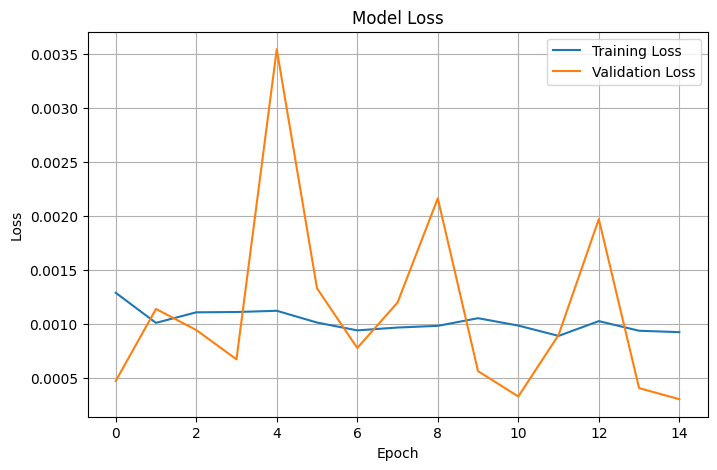

In [89]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.grid(True)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [90]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))
model.save("reliance_lstm_model.keras")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


In [91]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = math.sqrt(mse)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 18.902638288949035
Mean Squared Error (MSE): 595.1309565750113
Root Mean Squared Error (RMSE): 24.395306035690787


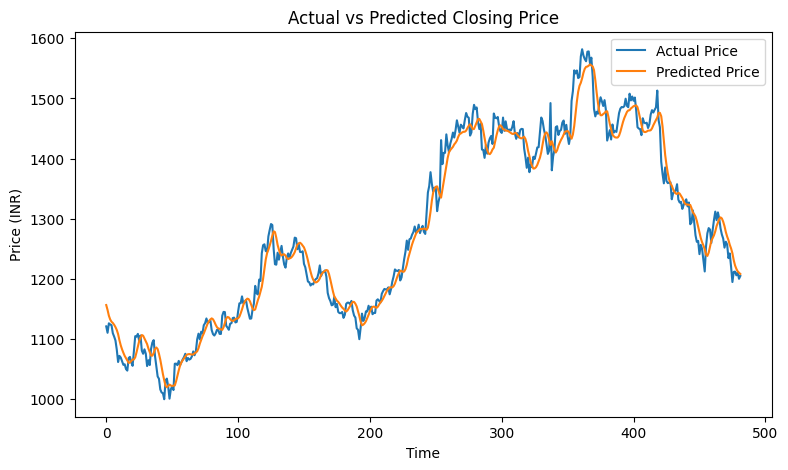

In [92]:
plt.figure(figsize=(9, 5))

plt.plot(y_test, label='Actual Price')
plt.plot(predictions, label='Predicted Price')

plt.title('Actual vs Predicted Closing Price')
plt.xlabel('Time')
plt.ylabel('Price (INR)')
plt.legend()

plt.show()

In [93]:
last_50_days = scaled_data[-50:]
last_50_days = last_50_days.reshape(1, 50, 1)

next_day = model.predict(last_50_days)

next_day = scaler.inverse_transform(next_day)

print("Predicted Next Day Closing Price:", next_day[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
Predicted Next Day Closing Price: 1207.1995
